#1. Import Dataset

In [ ]:
import tensorflow as tf


In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [ ]:
df_wind = pd.read_csv("/content/drive/My Drive/TA/Dataset/NO2_u_v_Land_Sea_Grid_Jabar.csv")
df_NO2_land = pd.read_csv("/content/drive/My Drive/TA/Dataset/NO2_Land_Grid_Jabar.csv")
df_NO2_sea = pd.read_csv("/content/drive/My Drive/TA/Dataset/NO2_Sea_Grid_Jabar.csv")
df_wind = df_wind[["date","u10","v10","longitude","latitude"]]

In [ ]:
# no2_df = pd.read_csv("/content/drive/MyDrive/TA/Dataset/no2.csv")
# wind_df=  pd.read_csv("/content/drive/MyDrive/TA/Dataset/wind.csv")
# no2_sea = pd.read_csv("/content/drive/MyDrive/TA/Dataset/Sea/NO2_Sea_wind.csv")

#2. Class Definition

In [ ]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

#Untuk Membangun Fourier Feature dengan Banyak Initial Sigma
class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)


#Untuk Membangun Fourier Feature pad Satu Initial Sigma
class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Pakai RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='tanh',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  #X = [t, x, y] harus tensor
        X = tf.reshape(X, (-1, 3))  # Memastikan Dimensi input (batch_size, features) untuk [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z) #melakukan fourier freatures dengan multisigma
        for i in range(self.num_hidden_layers): #hidden layers
            Z = self.hidden[i](Z)
        return self.out(Z)

class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self, t, x, y, u_data, Wu=None, Wv=None): # Added default None for Wu, Wv
        return self.get_r_fn(t=t, x=x, y=y, model=self.model, lambd = self.lambd, fun_r=self.fun_r, u_data=u_data, Wu=Wu, Wv=Wv)


    def loss_fn(self, X, u, Wu, Wv):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        t = X[:, 0:1]
        x = X[:, 1:2]
        y = X[:, 2:3]
        r = self.get_r(t, x, y, u, Wu, Wv)
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u, Wu, Wv):
        X = tf.cast(X, tf.float32)
        u = tf.cast(u, tf.float32)
        Wu = tf.cast(Wu, tf.float32)
        Wv = tf.cast(Wv, tf.float32)


        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u, Wu, Wv)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, W_u, W_v, inverse=True, N=None, min_loss=None, timeout=None, batch_size=None):
        """
        Modified training loop that keeps the loss_callback function and reports loss per iteration.
        """
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)
        W_u = tf.convert_to_tensor(W_u, dtype=tf.float32)
        W_v = tf.convert_to_tensor(W_v, dtype=tf.float32)


        data = tf.data.Dataset.from_tensor_slices((X, u, W_u, W_v))

        if batch_size is not None:
            data = data.shuffle(buffer_size=len(X)).batch(batch_size).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)
        else:
            data = data.batch(len(X)).map(
                lambda x, u_batch, wu, wv: (tf.cast(x, tf.float32), tf.cast(u_batch, tf.float32), tf.cast(wu, tf.float32), tf.cast(wv, tf.float32))
            ).prefetch(tf.data.AUTOTUNE)


        # The loss_callback now accepts the results of a step as arguments.
        def loss_callback(loss, phi_r, epoch_num):
            self.current_loss = loss.numpy()
            self.phi_r = phi_r.numpy()

            # Print every 50 iterations to avoid excessive output
            if self.iter % 50 == 0:
                print(f"Epoch {epoch_num}, Iteration {self.iter}, Loss: {self.current_loss:.6e}, Phi_r: {self.phi_r:.6e}")

            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        epochs = N if N is not None else 1000 # Set a default number of epochs if N isn't specified

        # Explicit loops for epochs and iterations (batches)
        for epoch in range(epochs):
            if timeout is not None and (time.time() - start_time > timeout):
                print("Timeout reached. Stopping training.")
                break

            total_epoch_loss = 0
            num_batches = 0
            for batch_X, batch_u, batch_Wu, batch_Wv in data:
                # Execute one training step (one batch)
                loss, grads = self.get_grad(batch_X, batch_u, batch_Wu, batch_Wv)
                optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

                # Accumulate loss for the epoch
                total_epoch_loss += loss.numpy()
                num_batches += 1

                # Recalculate phi_r for reporting (optional, can be removed for speed)
                # phi_r = self.loss_fn(batch_X, batch_u, batch_Wu, batch_Wv)[1]
                # loss_callback(loss, phi_r, epoch + 1) # Callback per batch (noisy)

            # Calculate average epoch loss and call callback once per epoch
            avg_epoch_loss = total_epoch_loss / num_batches if num_batches > 0 else 0
            # We don't have phi_r readily available as it's calculated per batch,
            # so we'll just report the average epoch loss.
            self.current_loss = avg_epoch_loss
            self.hist.append(self.current_loss)
            self.iter += 1 # Increment iteration counter once per epoch

            # Print every epoch
            print(f"--- End of Epoch {epoch+1}, Iteration {self.iter}, Average Epoch Loss: {self.current_loss:.6e} ---")


            if min_loss is not None and self.current_loss < min_loss:
                print(f"Minimum loss of {min_loss} reached. Stopping training.")
                break


    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



#self disini adalah modelnya
def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]
    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

#Arsitektur dari H-PINN (inherit dari arsitektur PINN)
class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        return super().trainable_variables + [self.lambd]

#Cara optimasi dari HPINN
class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param,
                           X, u, W_u, W_v,
                           N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None,
                               modified=False, **kwargs):

        self.changed = False
        self.lambd_list = []

        # ================================
        # Forward optimization (NO batching, full dataset)
        # ================================
        print("\n\nForward optimization (full dataset)")
        self.iter = 0
        self.hist = []
        import time
        start_time = time.time()

        @tf.function
        def train_step_fwd():
            with tf.GradientTape() as tape:
                loss, _ = self.loss_fn(X, u, W_u, W_v) # Pass W_u, W_v here
            grads = tape.gradient(loss, self.model.trainable_variables)
            optim_fwd.apply_gradients(zip(grads, self.model.trainable_variables))
            return loss

        if N_fwd is not None:
            N_fwd = int(N_fwd)
            for _ in range(N_fwd):
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
            print(f"{N_fwd} forward iterations reached.")
        elif min_loss_fwd is not None:
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                if self.current_loss < min_loss_fwd:
                    print(f"Forward loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_fwd is not None:
            stop_after = time.time() + timeout_fwd
            while True:
                loss = train_step_fwd()
                self.current_loss = loss.numpy()
                self.hist.append(self.current_loss)
                self.iter += 1
                print(f"Iteration {self.iter}, Loss: {self.current_loss}")
                if time.time() > stop_after:
                    print(f"Forward timeout reached ({time.time()-start_time:.1f}s)")
                    break

        # ================================
        # Add PDE parameters
        # ================================
        self.model.add_param()
        self.changed = True
        print('\n\nFinding PDE parameters...')

        # ================================
        # Lambda penalty
        # ================================
        def lambda_penalty_hinge(lam=self.model.lambd, lam_min=1e-3, alpha=1e-2):
            return alpha * tf.square(tf.nn.relu(lam_min - lam))

        # ================================
        # Inverse optimization
        # ================================
        if modified:
            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param(self.t, self.x, self.y, W_u, W_v, self.model)
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss
        else:
            @tf.function
            def train_step_param():
                with tf.GradientTape(persistent=True) as tape_lambd: # Make tape persistent
                    tape_lambd.watch(self.model.lambd)
                    loss = self.get_r(self.t, self.x, self.y, u, W_u, W_v) # Pass arguments here
                    loss += lambda_penalty_hinge(self.model.lambd, lam_min=1e-3, alpha=1e-2)
                grad_lambd = tape_lambd.gradient(loss, self.model.lambd)
                del tape_lambd # Delete tape when done
                optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                return loss

        def callback():
            lambd = self.model.lambd.numpy()
            self.model.lambd_list.append(lambd)
            if self.iter % 10 == 0:
                print(f"It {self.iter:05d}: loss = {self.current_loss:.3e} lambda = {lambd}")
            self.hist.append(self.current_loss)
            self.iter += 1

        def loss_callback():
            loss = train_step_param()
            self.current_loss = loss.numpy()
            callback()

        start_time = time.time()
        if N_param is not None:
            N_param = int(N_param)
            for _ in range(N_param):
                loss_callback()
            print(f"{N_param} inverse iterations reached.")
        elif min_loss_param is not None:
            while True:
                loss_callback()
                if self.current_loss < min_loss_param:
                    print(f"Inverse loss target reached: {self.current_loss:.3e}")
                    break
        elif timeout_param is not None:
            stop_after = time.time() + timeout_param
            while True:
                loss_callback()
                if time.time() > stop_after:
                    print(f"Inverse timeout reached ({time.time()-start_time:.1f}s)")
                    break

    # ======================================================
    # Loss fn takes full dataset
    # ======================================================
    def loss_fn(self, X, u, Wu, Wv): # Added Wu, Wv here
        if self.changed:
            t = X[:, 0:1]
            x = X[:, 1:2]
            y = X[:, 2:3]
            r = self.get_r(t, x, y, u, Wu, Wv) # Pass arguments here
            loss = r
            return loss, r
        else:
            u_pred = self.model(X)
            loss = tf.reduce_mean(tf.square(u - u_pred))
            return loss, 0.0

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print(f"It {self.iter:05d}: l_u = {self.phi_0_b:.3e} loss = {self.current_loss:.3e}")
        self.hist.append(self.current_loss)
        self.iter += 1

# Pra-pemrosesan Data

In [ ]:
df_NO2_land

,date,mean_no2,longitude,latitude,type
0,2023-05-01,0.000038,105.121553,-6.599556,land
1,2023-05-01,NaN,105.131779,-6.578907,land
2,2023-05-01,NaN,105.166451,-6.660167,land
3,2023-05-01,0.000038,105.142537,-6.587084,land
4,2023-05-01,0.000038,105.155776,-6.567700,land
...,...,...,...,...,...
1972455,2025-04-29,0.000062,108.788361,-6.879599,land
1972456,2025-04-29,0.000061,108.797308,-6.848762,land
1972457,2025-04-29,0.000054,108.802493,-6.813819,land
1972458,2025-04-29,0.000062,108.819583,-6.831789,land


In [ ]:
df_NO2_land['date'] = pd.to_datetime(df_NO2_land['date'])

df_NO2_land.describe()

,date,mean_no2,longitude,latitude
count,1972460,1.837630e+06,1.972460e+06,1.972460e+06
mean,2024-04-29 11:59:59.999999744,6.665154e-05,1.072626e+02,-6.811237e+00
min,2023-05-01 00:00:00,-7.323073e-05,1.051216e+02,-7.790881e+00
25%,2023-10-30 00:00:00,4.745234e-05,1.065985e+02,-7.149168e+00
50%,2024-04-29 12:00:00,5.795583e-05,1.072904e+02,-6.803368e+00
75%,2024-10-29 00:00:00,7.489232e-05,1.079823e+02,-6.457568e+00
max,2025-04-29 00:00:00,7.595590e-04,1.088223e+02,-5.809611e+00
std,NaN,3.269006e-05,8.677472e-01,4.551894e-01


In [ ]:
df_NO2_sea

,date,mean_no2,longitude,latitude,type
0,2023-05-01,0.000042,105.023528,-6.842984,sea
1,2023-05-01,0.000038,105.003719,-6.767207,sea
2,2023-05-01,0.000032,104.974697,-6.678569,sea
3,2023-05-01,0.000037,104.968469,-6.583673,sea
4,2023-05-01,0.000045,104.985761,-6.490722,sea
...,...,...,...,...,...
245275,2025-04-29,0.000046,108.959799,-6.977997,sea
245276,2025-04-29,0.000055,108.974448,-6.876551,sea
245277,2025-04-29,0.000058,108.980321,-6.781030,sea
245278,2025-04-29,0.000048,108.967292,-6.688445,sea


In [ ]:
df_NO2_sea['date'] = pd.to_datetime(df_NO2_sea['date'])
df_NO2_sea.describe()

,date,mean_no2,longitude,latitude
count,245280,231456.000000,245280.000000,245280.000000
mean,2024-04-29 11:59:59.999999232,0.000056,107.086026,-6.729896
min,2023-05-01 00:00:00,-0.000078,104.968469,-7.964794
25%,2023-10-30 00:00:00,0.000043,105.955116,-7.374820
50%,2024-04-29 12:00:00,0.000050,106.988313,-6.681646
75%,2024-10-29 00:00:00,0.000060,108.363237,-6.060573
max,2025-04-29 00:00:00,0.000731,108.980321,-5.627853
std,NaN,0.000026,1.249204,0.699419


In [ ]:
df_wind

,date,u10,v10,longitude,latitude
0,2023-05-01,3.051666,0.443444,105.121553,-6.599556
1,2023-05-01,NaN,NaN,105.131779,-6.578907
2,2023-05-01,NaN,NaN,105.166451,-6.660167
3,2023-05-01,3.051666,0.443444,105.142537,-6.587084
4,2023-05-01,3.051666,0.443444,105.155776,-6.567700
...,...,...,...,...,...
2217735,2025-04-29,-0.229289,1.028061,108.959799,-6.977997
2217736,2025-04-29,-0.335416,0.799943,108.974448,-6.876551
2217737,2025-04-29,-0.346069,0.777044,108.980321,-6.781030
2217738,2025-04-29,-0.397578,0.788718,108.967292,-6.688445


In [ ]:
df_wind['date'] = pd.to_datetime(df_wind['date'])
df_wind.describe()

,date,u10,v10,longitude,latitude
count,2217740,2.179780e+06,2.179780e+06,2.217740e+06,2.217740e+06
mean,2024-04-29 11:59:59.999999232,-3.593442e-01,5.434387e-01,1.072431e+02,-6.802240e+00
min,2023-05-01 00:00:00,-1.048142e+01,-8.637797e+00,1.049685e+02,-7.964794e+00
25%,2023-10-30 00:00:00,-1.153536e+00,-2.025598e-01,1.065356e+02,-7.198568e+00
50%,2024-04-29 12:00:00,-2.661079e-01,2.674626e-01,1.072904e+02,-6.795276e+00
75%,2024-10-29 00:00:00,3.842758e-01,1.079323e+00,1.080138e+02,-6.408168e+00
max,2025-04-29 00:00:00,1.183138e+01,9.490511e+00,1.089803e+02,-5.627853e+00
std,NaN,1.958993e+00,1.431592e+00,9.194360e-01,4.889128e-01


In [ ]:
df = pd.concat([df_NO2_land,df_NO2_sea],axis=0)
df['date'] = pd.to_datetime(df['date'])
start_date = datetime.datetime(2023, 5, 1)
df = df[(df['date'] >= start_date)]
df=df.rename(columns={"longitude":"x_coord","latitude":"y_coord"})
df_wind=df_wind.rename(columns={"longitude":"x_coord","latitude":"y_coord"})
df.sort_values(by=['date','x_coord','y_coord'], inplace=True)

In [ ]:
#Kondisi setelah data NO_sea dan NO_land digabungkan
df

,date,mean_no2,x_coord,y_coord,type
3,2023-05-01,0.000037,104.968469,-6.583673,sea
2,2023-05-01,0.000032,104.974697,-6.678569,sea
4,2023-05-01,0.000045,104.985761,-6.490722,sea
1,2023-05-01,0.000038,105.003719,-6.767207,sea
5,2023-05-01,0.000041,105.014849,-6.423209,sea
...,...,...,...,...,...
245275,2025-04-29,0.000046,108.959799,-6.977997,sea
245269,2025-04-29,0.000042,108.960063,-7.670531,sea
245278,2025-04-29,0.000048,108.967292,-6.688445,sea
245276,2025-04-29,0.000055,108.974448,-6.876551,sea


In [ ]:
df.describe()

,date,mean_no2,x_coord,y_coord
count,2217740,2.069086e+06,2.217740e+06,2.217740e+06
mean,2024-04-29 11:59:59.999999232,6.545823e-05,1.072431e+02,-6.802240e+00
min,2023-05-01 00:00:00,-7.808937e-05,1.049685e+02,-7.964794e+00
25%,2023-10-30 00:00:00,4.683880e-05,1.065356e+02,-7.198568e+00
50%,2024-04-29 12:00:00,5.688063e-05,1.072904e+02,-6.795276e+00
75%,2024-10-29 00:00:00,7.321140e-05,1.080138e+02,-6.408168e+00
max,2025-04-29 00:00:00,7.595590e-04,1.089803e+02,-5.627853e+00
std,NaN,3.219860e-05,9.194360e-01,4.889128e-01


## Pembersihan Data Polusi

In [ ]:
df.dropna(inplace=True)
df_wind.dropna(inplace=True)

In [ ]:
df

,date,mean_no2,x_coord,y_coord,type
3,2023-05-01,0.000037,104.968469,-6.583673,sea
2,2023-05-01,0.000032,104.974697,-6.678569,sea
4,2023-05-01,0.000045,104.985761,-6.490722,sea
1,2023-05-01,0.000038,105.003719,-6.767207,sea
5,2023-05-01,0.000041,105.014849,-6.423209,sea
...,...,...,...,...,...
245275,2025-04-29,0.000046,108.959799,-6.977997,sea
245269,2025-04-29,0.000042,108.960063,-7.670531,sea
245278,2025-04-29,0.000048,108.967292,-6.688445,sea
245276,2025-04-29,0.000055,108.974448,-6.876551,sea


In [ ]:
df.describe()

,date,mean_no2,x_coord,y_coord
count,2069086,2.069086e+06,2.069086e+06,2.069086e+06
mean,2024-04-29 05:45:51.632363008,6.545823e-05,1.072537e+02,-6.812564e+00
min,2023-05-01 00:00:00,-7.808937e-05,1.049685e+02,-7.964794e+00
25%,2023-10-27 00:00:00,4.683880e-05,1.065451e+02,-7.198568e+00
50%,2024-05-02 00:00:00,5.688063e-05,1.073219e+02,-6.803368e+00
75%,2024-10-27 00:00:00,7.321140e-05,1.080138e+02,-6.457568e+00
max,2025-04-29 00:00:00,7.595590e-04,1.089803e+02,-5.627853e+00
std,NaN,3.219860e-05,9.147239e-01,4.870808e-01


In [ ]:
df_wind

,date,u10,v10,x_coord,y_coord
0,2023-05-01,3.051666,0.443444,105.121553,-6.599556
3,2023-05-01,3.051666,0.443444,105.142537,-6.587084
4,2023-05-01,3.051666,0.443444,105.155776,-6.567700
5,2023-05-01,3.229481,0.295413,105.184081,-6.652490
6,2023-05-01,3.051666,0.443444,105.187504,-6.601225
...,...,...,...,...,...
2217735,2025-04-29,-0.229289,1.028061,108.959799,-6.977997
2217736,2025-04-29,-0.335416,0.799943,108.974448,-6.876551
2217737,2025-04-29,-0.346069,0.777044,108.980321,-6.781030
2217738,2025-04-29,-0.397578,0.788718,108.967292,-6.688445


In [ ]:
df_wind.describe()

,date,u10,v10,x_coord,y_coord
count,2179780,2.179780e+06,2.179780e+06,2.179780e+06,2.179780e+06
mean,2024-04-29 11:59:59.999999744,-3.593442e-01,5.434387e-01,1.072465e+02,-6.805420e+00
min,2023-05-01 00:00:00,-1.048142e+01,-8.637797e+00,1.049685e+02,-7.964794e+00
25%,2023-10-30 00:00:00,-1.153536e+00,-2.025598e-01,1.065361e+02,-7.198568e+00
50%,2024-04-29 12:00:00,-2.661079e-01,2.674626e-01,1.072904e+02,-6.801260e+00
75%,2024-10-29 00:00:00,3.842758e-01,1.079323e+00,1.080138e+02,-6.429441e+00
max,2025-04-29 00:00:00,1.183138e+01,9.490511e+00,1.089803e+02,-5.627853e+00
std,NaN,1.958993e+00,1.431592e+00,9.136564e-01,4.853140e-01


In [ ]:
df=df.rename(columns={"mean_no2":"NO2_mean"})
df = df[df.NO2_mean>=0]
df_wind['date'] = pd.to_datetime(df_wind['date'])
merged_df = pd.merge(df, df_wind, on=['date','x_coord', 'y_coord'], how='inner')


In [ ]:
merged_df

,date,NO2_mean,x_coord,y_coord,type,u10,v10
0,2023-05-01,0.000037,104.968469,-6.583673,sea,3.388731,0.421293
1,2023-05-01,0.000032,104.974697,-6.678569,sea,3.398302,0.336797
2,2023-05-01,0.000045,104.985761,-6.490722,sea,3.388731,0.421293
3,2023-05-01,0.000038,105.003719,-6.767207,sea,3.399855,0.323086
4,2023-05-01,0.000041,105.014849,-6.423209,sea,3.388731,0.421293
...,...,...,...,...,...,...,...
2067986,2025-04-29,0.000046,108.959799,-6.977997,sea,-0.229289,1.028061
2067987,2025-04-29,0.000042,108.960063,-7.670531,sea,-4.023875,0.713078
2067988,2025-04-29,0.000048,108.967292,-6.688445,sea,-0.397578,0.788718
2067989,2025-04-29,0.000055,108.974448,-6.876551,sea,-0.335416,0.799943


In [ ]:
merged_df.describe()

,date,NO2_mean,x_coord,y_coord,u10,v10
count,2067991,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06
mean,2024-04-29 04:19:46.911935232,6.549887e-05,1.072538e+02,-6.812484e+00,-3.844047e-01,5.563342e-01
min,2023-05-01 00:00:00,3.293232e-08,1.049685e+02,-7.964794e+00,-1.048142e+01,-8.637797e+00
25%,2023-10-27 00:00:00,4.685484e-05,1.065631e+02,-7.198568e+00,-1.183015e+00,-1.986510e-01
50%,2024-05-01 00:00:00,5.689299e-05,1.073219e+02,-6.803368e+00,-2.816284e-01,2.749262e-01
75%,2024-10-27 00:00:00,7.322430e-05,1.080138e+02,-6.457568e+00,3.576806e-01,1.100528e+00
max,2025-04-29 00:00:00,7.595590e-04,1.089803e+02,-5.627853e+00,1.183138e+01,9.490511e+00
std,NaN,3.215752e-05,9.146657e-01,4.870695e-01,1.962911e+00,1.439894e+00


## Rata-rata Kecepatan Angin

In [ ]:
merged_df= merged_df.rename(columns = {"u_component_of_wind_10m":'u10',"v_component_of_wind_10m":'v10'})
merged_df = merged_df[["date","NO2_mean","u10","v10","x_coord","y_coord"]]

merged_df['u10']  = merged_df.groupby(['x_coord','y_coord'])['u10'].transform('mean')
merged_df['v10']  = merged_df.groupby(['x_coord','y_coord'])['v10'].transform('mean')

In [ ]:
merged_df

,date,NO2_mean,u10,v10,x_coord,y_coord
0,2023-05-01,0.000037,-1.456817,2.620880,104.968469,-6.583673
1,2023-05-01,0.000032,-1.868967,2.673767,104.974697,-6.678569
2,2023-05-01,0.000045,-1.471896,2.629114,104.985761,-6.490722
3,2023-05-01,0.000038,-1.915248,2.678548,105.003719,-6.767207
4,2023-05-01,0.000041,-1.458031,2.633309,105.014849,-6.423209
...,...,...,...,...,...,...
2067986,2025-04-29,0.000046,0.061295,0.814819,108.959799,-6.977997
2067987,2025-04-29,0.000042,-1.171818,0.910081,108.960063,-7.670531
2067988,2025-04-29,0.000048,0.402193,0.759426,108.967292,-6.688445
2067989,2025-04-29,0.000055,0.398165,0.741260,108.974448,-6.876551


In [ ]:
merged_df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord
count,2067991,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06
mean,2024-04-29 04:19:46.911935232,6.549887e-05,-3.844047e-01,5.563342e-01,1.072538e+02,-6.812484e+00
min,2023-05-01 00:00:00,3.293232e-08,-3.046046e+00,-3.834911e-01,1.049685e+02,-7.964794e+00
25%,2023-10-27 00:00:00,4.685484e-05,-6.623608e-01,4.911434e-02,1.065631e+02,-7.198568e+00
50%,2024-05-01 00:00:00,5.689299e-05,-2.165027e-01,3.295166e-01,1.073219e+02,-6.803368e+00
75%,2024-10-27 00:00:00,7.322430e-05,8.370852e-02,9.535318e-01,1.080138e+02,-6.457568e+00
max,2025-04-29 00:00:00,7.595590e-04,7.784493e-01,2.839143e+00,1.089803e+02,-5.627853e+00
std,NaN,3.215752e-05,6.479997e-01,6.939365e-01,9.146657e-01,4.870695e-01


/tmp/ipython-input-4011362533.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-4011362533.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


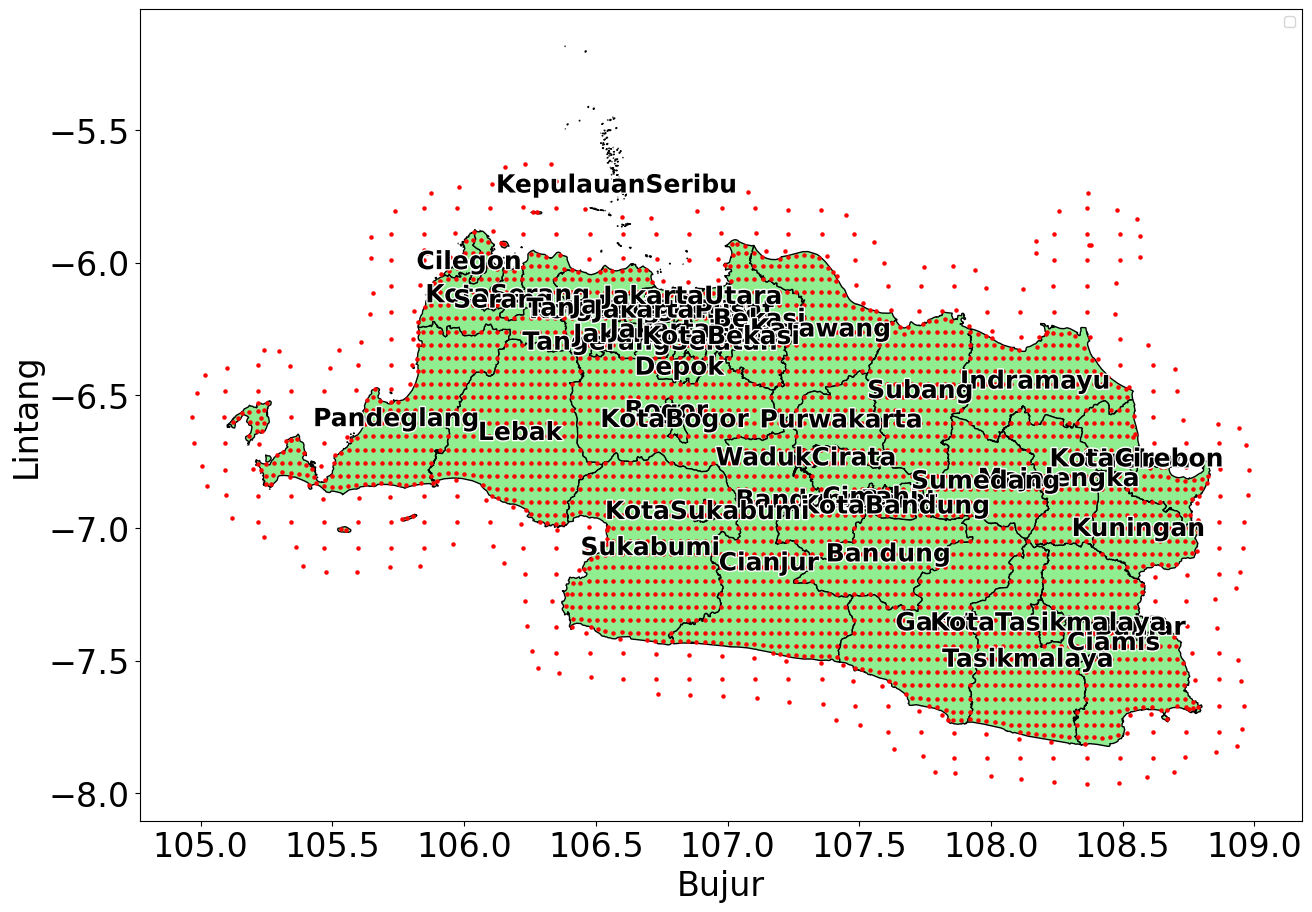

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.patheffects as pe

# Load shapefile of Indonesia level-2
indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# Create geometry column in df
df['geometry'] = [Point(xy) for xy in zip(df['x_coord'], df['y_coord'])]
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')


jawa_prov = ['JakartaRaya', 'JawaBarat','Banten']
jawa = indonesia[indonesia['NAME_1'].isin(jawa_prov)]
jawa['centroid'] = jawa.geometry.centroid


# Plot peta Jawa
fig, ax = plt.subplots(figsize=(15,15))
jawa.plot(ax=ax, color='lightgreen', edgecolor='black')

cities_unique = gdf.drop_duplicates(subset=['x_coord', 'y_coord'])

for idx, row in jawa.iterrows():
          ax.annotate(
              text=row['NAME_2'],
              xy=(row['centroid'].x, row['centroid'].y),
              ha='center', va='center',
              fontsize=18, color='black', weight='bold',
              path_effects=[pe.withStroke(linewidth=2, foreground="white")]
          )

cities_unique.plot(ax=ax, color='red', markersize=5)

# Tambahkan judul dan legenda
plt.legend()

plt.xlabel('Bujur', fontsize = 24)
plt.ylabel('Lintang', fontsize = 24)
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.show()

/tmp/ipython-input-3747410134.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipython-input-3747410134.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


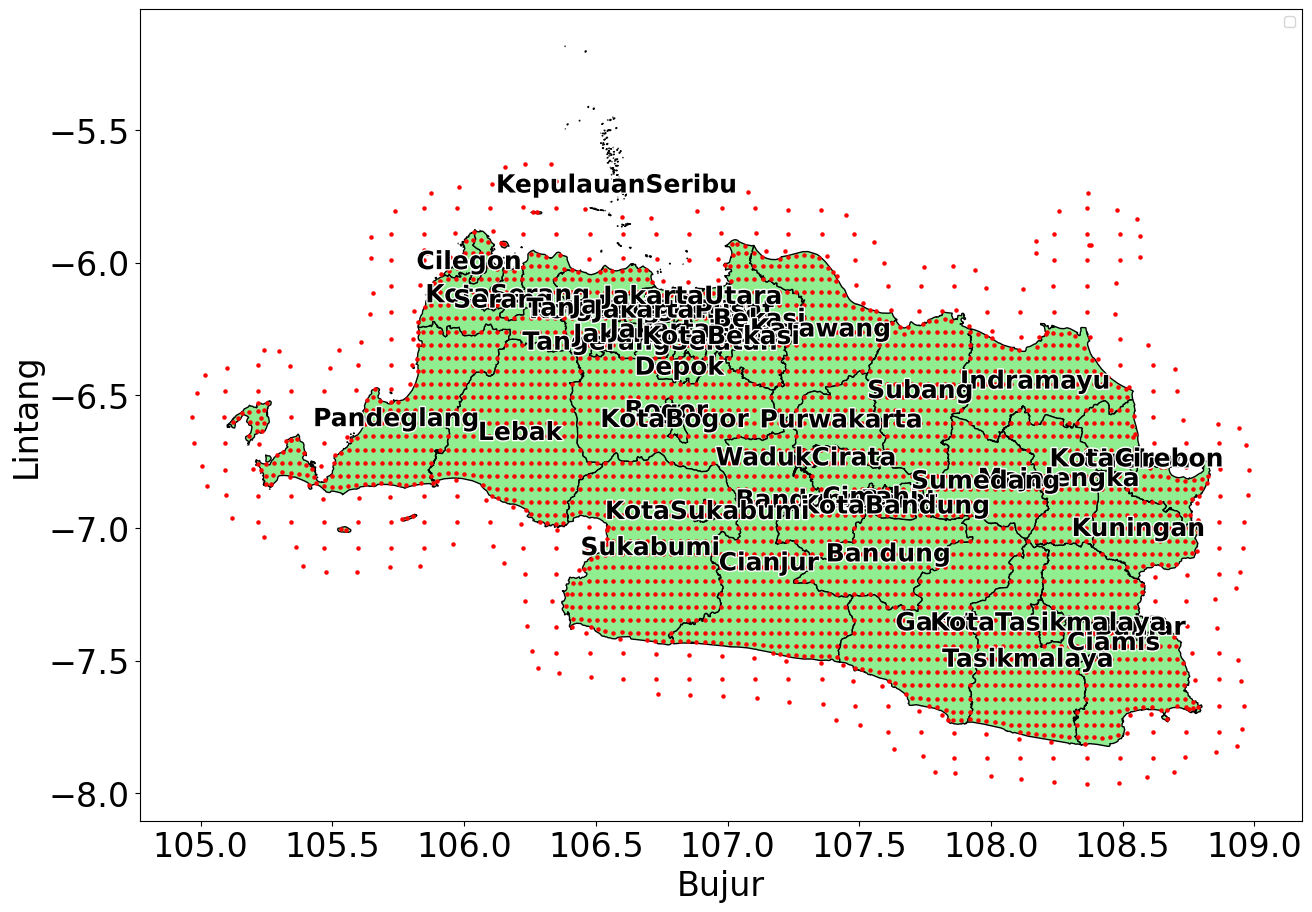

In [ ]:
# Load shapefile of Indonesia level-2
# indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

# Create geometry column in df
merged_df['geometry'] = [Point(xy) for xy in zip(merged_df['x_coord'], merged_df['y_coord'])]
gdf = gpd.GeoDataFrame(merged_df, geometry='geometry', crs='EPSG:4326')

jawa_prov = ['JakartaRaya', 'JawaBarat','Banten']
jawa = indonesia[indonesia['NAME_1'].isin(jawa_prov)]
jawa['centroid'] = jawa.geometry.centroid

# Plot peta Jawa
fig, ax = plt.subplots(figsize=(15,15))
jawa.plot(ax=ax, color='lightgreen', edgecolor='black')

cities_unique = gdf.drop_duplicates(subset=['x_coord', 'y_coord'])

for idx, row in jawa.iterrows():
          ax.annotate(
              text=row['NAME_2'],
              xy=(row['centroid'].x, row['centroid'].y),
              ha='center', va='center',
              fontsize=18, color='black', weight='bold',
              path_effects=[pe.withStroke(linewidth=2, foreground="white")]
          )

cities_unique.plot(ax=ax, color='red', markersize=5)

# Tambahkan judul dan legenda
plt.legend()

plt.xlabel('Bujur', fontsize = 24)
plt.ylabel('Lintang', fontsize = 24)
plt.xticks(fontsize = 24)
plt.yticks(fontsize = 24)
plt.show()

In [ ]:
merged_df = merged_df[["date","NO2_mean","u10","v10","x_coord","y_coord"]]

## Teknik Rescaling

In [ ]:
#Convert to Numerical Value
merged_df['time'] = (merged_df['date'] - merged_df['date'].min()).dt.days
scale = 1e-5
merged_df.NO2_mean = merged_df.NO2_mean/scale
merged_df.x_coord = merged_df.x_coord*100
merged_df.y_coord = merged_df.y_coord*100

In [ ]:
merged_df

,date,NO2_mean,u10,v10,x_coord,y_coord,time
0,2023-05-01,3.686948,-1.456817,2.620880,10496.846881,-658.367252,0
1,2023-05-01,3.161125,-1.868967,2.673767,10497.469700,-667.856897,0
2,2023-05-01,4.473013,-1.471896,2.629114,10498.576128,-649.072249,0
3,2023-05-01,3.798790,-1.915248,2.678548,10500.371938,-676.720681,0
4,2023-05-01,4.126300,-1.458031,2.633309,10501.484859,-642.320911,0
...,...,...,...,...,...,...,...
2067986,2025-04-29,4.591356,0.061295,0.814819,10895.979937,-697.799717,729
2067987,2025-04-29,4.177431,-1.171818,0.910081,10896.006322,-767.053058,729
2067988,2025-04-29,4.823056,0.402193,0.759426,10896.729247,-668.844519,729
2067989,2025-04-29,5.467621,0.398165,0.741260,10897.444849,-687.655138,729


In [ ]:
merged_df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time
count,2067991,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06
mean,2024-04-29 04:19:46.911935232,6.549887e+00,-3.844047e-01,5.563342e-01,1.072538e+04,-6.812484e+02,3.641804e+02
min,2023-05-01 00:00:00,3.293232e-03,-3.046046e+00,-3.834911e-01,1.049685e+04,-7.964794e+02,0.000000e+00
25%,2023-10-27 00:00:00,4.685484e+00,-6.623608e-01,4.911434e-02,1.065631e+04,-7.198568e+02,1.790000e+02
50%,2024-05-01 00:00:00,5.689299e+00,-2.165027e-01,3.295166e-01,1.073219e+04,-6.803368e+02,3.660000e+02
75%,2024-10-27 00:00:00,7.322430e+00,8.370852e-02,9.535318e-01,1.080138e+04,-6.457568e+02,5.450000e+02
max,2025-04-29 00:00:00,7.595590e+01,7.784493e-01,2.839143e+00,1.089803e+04,-5.627853e+02,7.290000e+02
std,NaN,3.215752e+00,6.479997e-01,6.939365e-01,9.146657e+01,4.870695e+01,2.108942e+02


## Lowpass FIltering dan Cek Normalitas Residu

In [ ]:
def low_pass_filter(series, cutoff=0.3):
    """Applies a low-pass filter to a pandas Series."""
    signal = series.values
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), d=1) # d=1 assumes unit time spacing

    # Apply the ideal low-pass filter
    mask = np.abs(freqs) < cutoff
    filtered_fft = fft_vals * mask

    # Return the real part of the inverse FFT
    return np.fft.ifft(filtered_fft).real

full_dates = pd.date_range(start=merged_df['date'].min(),end=merged_df['date'].max(),freq='D')
merged_df2 = (merged_df.set_index('date').groupby(['x_coord', 'y_coord']).apply(lambda g: g.reindex(full_dates)).reset_index(level=[0,1]).rename_axis('date').reset_index())
merged_df2['NO2_mean'] = (merged_df2.groupby(['x_coord', 'y_coord'])['NO2_mean'].apply(lambda s: s.interpolate(method='linear', limit_direction='both')))
merged_df['NO2_filtered'] = merged_df.groupby(['x_coord', 'y_coord'])['NO2_mean'].transform(low_pass_filter)
merged_df = merged_df[['date', 'NO2_mean','u10','v10','x_coord', 'y_coord','time']].merge(
    merged_df[['date', 'x_coord', 'y_coord', 'NO2_filtered']],
    on=['date', 'x_coord', 'y_coord'],
    how='left'
)

# 'merged_df' now contains the new 'NO2_filtered' column with the results.
print(merged_df.head())

        date  NO2_mean       u10       v10       x_coord     y_coord  time  \
0 2023-05-01  3.686948 -1.456817  2.620880  10496.846881 -658.367252     0   
1 2023-05-01  3.161125 -1.868967  2.673767  10497.469700 -667.856897     0   
2 2023-05-01  4.473013 -1.471896  2.629114  10498.576128 -649.072249     0   
3 2023-05-01  3.798790 -1.915248  2.678548  10500.371938 -676.720681     0   
4 2023-05-01  4.126300 -1.458031  2.633309  10501.484859 -642.320911     0   

   NO2_filtered  
0      3.622362  
1      3.239815  
2      3.995393  
3      3.776947  
4      4.141185  


In [ ]:
merged_df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time,NO2_filtered
count,2067991,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06
mean,2024-04-29 04:19:46.911935232,6.549887e+00,-3.844047e-01,5.563342e-01,1.072538e+04,-6.812484e+02,3.641804e+02,6.549887e+00
min,2023-05-01 00:00:00,3.293232e-03,-3.046046e+00,-3.834911e-01,1.049685e+04,-7.964794e+02,0.000000e+00,-3.511201e-01
25%,2023-10-27 00:00:00,4.685484e+00,-6.623608e-01,4.911434e-02,1.065631e+04,-7.198568e+02,1.790000e+02,4.732100e+00
50%,2024-05-01 00:00:00,5.689299e+00,-2.165027e-01,3.295166e-01,1.073219e+04,-6.803368e+02,3.660000e+02,5.730877e+00
75%,2024-10-27 00:00:00,7.322430e+00,8.370852e-02,9.535318e-01,1.080138e+04,-6.457568e+02,5.450000e+02,7.332399e+00
max,2025-04-29 00:00:00,7.595590e+01,7.784493e-01,2.839143e+00,1.089803e+04,-5.627853e+02,7.290000e+02,6.310808e+01
std,NaN,3.215752e+00,6.479997e-01,6.939365e-01,9.146657e+01,4.870695e+01,2.108942e+02,3.011861e+00


In [ ]:
from scipy.stats import kstest
import pandas as pd

# Assume 'filtered_df' is your DataFrame with NO2_mean and NO2_filtered columns

def check_normality(group):
    """
    Calculates KS test for normality on the residuals of a given group.
    """
    residuals = group['NO2_mean'] - group['NO2_filtered']
    std_residuals = residuals.std()

    # Handle cases where all residuals are the same
    if std_residuals == 0:
        return pd.Series({
            'Test Statistic (KS)': None,
            'P-value (KS)': None,
            'Normality (KS)': "Standard deviation is zero",
            'Data Points': len(residuals)
        })

    # Perform the KS test
    mean_residuals = residuals.mean()
    stat, p = kstest(residuals, 'norm', args=(mean_residuals, std_residuals))

    # Determine normality based on the p-value
    normality = "Gaussian" if p > 0.01 else "Not Gaussian"

    return pd.Series({
        'Test Statistic (KS)': stat,
        'P-value (KS)': p,
        'Normality (KS)': normality,
        'Data Points': len(residuals)
    })

# Group by coordinates only and apply the function
normality_results_df = merged_df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()

# Display the first few rows of the results
print(normality_results_df.head())

        x_coord     y_coord  Test Statistic (KS)  P-value (KS) Normality (KS)  \
0  10496.846881 -658.367252             0.094819      0.000004   Not Gaussian   
1  10497.469700 -667.856897             0.096442      0.000003   Not Gaussian   
2  10498.576128 -649.072249             0.066848      0.003029   Not Gaussian   
3  10500.371938 -676.720681             0.098120      0.000002   Not Gaussian   
4  10501.484859 -642.320911             0.079470      0.000252   Not Gaussian   

   Data Points  
0          723  
1          723  
2          721  
3          717  
4          706  


/tmp/ipython-input-3038680436.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normality_results_df = merged_df.groupby(['x_coord', 'y_coord']).apply(check_normality).reset_index()


In [ ]:
normality_results_df["Normality (KS)"].value_counts()

,count
Normality (KS),
Gaussian,2231
Not Gaussian,755


In [ ]:
merged_df.describe()

,date,NO2_mean,u10,v10,x_coord,y_coord,time,NO2_filtered
count,2067991,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06
mean,2024-04-29 04:19:46.911935232,6.549887e+00,-3.844047e-01,5.563342e-01,1.072538e+04,-6.812484e+02,3.641804e+02,6.549887e+00
min,2023-05-01 00:00:00,3.293232e-03,-3.046046e+00,-3.834911e-01,1.049685e+04,-7.964794e+02,0.000000e+00,-3.511201e-01
25%,2023-10-27 00:00:00,4.685484e+00,-6.623608e-01,4.911434e-02,1.065631e+04,-7.198568e+02,1.790000e+02,4.732100e+00
50%,2024-05-01 00:00:00,5.689299e+00,-2.165027e-01,3.295166e-01,1.073219e+04,-6.803368e+02,3.660000e+02,5.730877e+00
75%,2024-10-27 00:00:00,7.322430e+00,8.370852e-02,9.535318e-01,1.080138e+04,-6.457568e+02,5.450000e+02,7.332399e+00
max,2025-04-29 00:00:00,7.595590e+01,7.784493e-01,2.839143e+00,1.089803e+04,-5.627853e+02,7.290000e+02,6.310808e+01
std,NaN,3.215752e+00,6.479997e-01,6.939365e-01,9.146657e+01,4.870695e+01,2.108942e+02,3.011861e+00


In [ ]:
averaged_df = merged_df.groupby(['x_coord', 'y_coord'])[['u10', 'v10']].mean().reset_index()
df_for_update = merged_df.drop(columns=['u10', 'v10'])
filtered_df = pd.merge(df_for_update, averaged_df, on=['x_coord', 'y_coord'], how='left')
filtered_df

,date,NO2_mean,x_coord,y_coord,time,NO2_filtered,u10,v10
0,2023-05-01,3.686948,10496.846881,-658.367252,0,3.622362,-1.456817,2.620880
1,2023-05-01,3.161125,10497.469700,-667.856897,0,3.239815,-1.868967,2.673767
2,2023-05-01,4.473013,10498.576128,-649.072249,0,3.995393,-1.471896,2.629114
3,2023-05-01,3.798790,10500.371938,-676.720681,0,3.776947,-1.915248,2.678548
4,2023-05-01,4.126300,10501.484859,-642.320911,0,4.141185,-1.458031,2.633309
...,...,...,...,...,...,...,...,...
2067986,2025-04-29,4.591356,10895.979937,-697.799717,729,4.451998,0.061295,0.814819
2067987,2025-04-29,4.177431,10896.006322,-767.053058,729,3.886173,-1.171818,0.910081
2067988,2025-04-29,4.823056,10896.729247,-668.844519,729,4.308522,0.402193,0.759426
2067989,2025-04-29,5.467621,10897.444849,-687.655138,729,5.303885,0.398165,0.741260


In [ ]:
filtered_df

,date,NO2_mean,x_coord,y_coord,time,NO2_filtered,u10,v10
0,2023-05-01,3.686948,10496.846881,-658.367252,0,3.622362,-1.456817,2.620880
1,2023-05-01,3.161125,10497.469700,-667.856897,0,3.239815,-1.868967,2.673767
2,2023-05-01,4.473013,10498.576128,-649.072249,0,3.995393,-1.471896,2.629114
3,2023-05-01,3.798790,10500.371938,-676.720681,0,3.776947,-1.915248,2.678548
4,2023-05-01,4.126300,10501.484859,-642.320911,0,4.141185,-1.458031,2.633309
...,...,...,...,...,...,...,...,...
2067986,2025-04-29,4.591356,10895.979937,-697.799717,729,4.451998,0.061295,0.814819
2067987,2025-04-29,4.177431,10896.006322,-767.053058,729,3.886173,-1.171818,0.910081
2067988,2025-04-29,4.823056,10896.729247,-668.844519,729,4.308522,0.402193,0.759426
2067989,2025-04-29,5.467621,10897.444849,-687.655138,729,5.303885,0.398165,0.741260


In [ ]:
filtered_df.describe()

,date,NO2_mean,x_coord,y_coord,time,NO2_filtered,u10,v10
count,2067991,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06,2.067991e+06
mean,2024-04-29 04:19:46.911935232,6.549887e+00,1.072538e+04,-6.812484e+02,3.641804e+02,6.549887e+00,-3.844047e-01,5.563342e-01
min,2023-05-01 00:00:00,3.293232e-03,1.049685e+04,-7.964794e+02,0.000000e+00,-3.511201e-01,-3.046046e+00,-3.834911e-01
25%,2023-10-27 00:00:00,4.685484e+00,1.065631e+04,-7.198568e+02,1.790000e+02,4.732100e+00,-6.623608e-01,4.911434e-02
50%,2024-05-01 00:00:00,5.689299e+00,1.073219e+04,-6.803368e+02,3.660000e+02,5.730877e+00,-2.165027e-01,3.295166e-01
75%,2024-10-27 00:00:00,7.322430e+00,1.080138e+04,-6.457568e+02,5.450000e+02,7.332399e+00,8.370852e-02,9.535318e-01
max,2025-04-29 00:00:00,7.595590e+01,1.089803e+04,-5.627853e+02,7.290000e+02,6.310808e+01,7.784493e-01,2.839143e+00
std,NaN,3.215752e+00,9.146657e+01,4.870695e+01,2.108942e+02,3.011861e+00,6.479997e-01,6.939365e-01


In [ ]:
# Select up to 20 unique locations randomly follows "Gaussian"
gaussian_locations = normality_results_df[normality_results_df['Normality (KS)'] == 'Gaussian'][['x_coord', 'y_coord']]

selected_locations = gaussian_locations.sample(min(20, len(gaussian_locations)), random_state=42)

# Plot for each selected location
for index, row in selected_locations.iterrows():
    x_c, y_c = row['x_coord'], row['y_coord']

    # Filter data for the current location
    location_data = merged_df[(merged_df['x_coord'] == x_c) & (merged_df['y_coord'] == y_c)].copy()
    if location_data.empty:
        print(f"No data found for location ({x_c}, {y_c}). Skipping.")
        continue

    # Calculate residuals
    location_data['residuals'] = location_data['NO2_mean'] - location_data['NO2_filtered']

    # Sort by time for plotting
    location_data.sort_values(by='time', inplace=True)

    # --- Combined Plot ---
    plt.figure(figsize=(12, 4))
    plt.title(f'Konsentrasi NO2, Filtering, dan Residu di titik ({x_c/100:.2f}, {y_c/100:.2f})', fontsize=14)

    # Original data (blue)
    plt.plot(location_data['time'], location_data['NO2_mean'], label='Data Asli', color='blue')

    # Filtered data (orange)
    plt.plot(location_data['time'], location_data['NO2_filtered'], label='Data Hasil Filtering', color='orange')

    # Residuals (gray, transparent)
    plt.plot(location_data['time'], location_data['residuals'], label='Residu', color='gray', alpha=0.6)

    plt.xlabel("Waktu (t)")
    plt.ylabel("Konsentrasi NO2 dalam 10^-5 mol/m^2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Residuals Histogram ---
    plt.figure(figsize=(10, 6))
    plt.hist(location_data['residuals'], bins=40, color='gray', alpha=0.7, label='Residuals')
    plt.title(f'Distribusi Residu Filtering di titik ({x_c/100:.2f}, {y_c/100:.2f})')
    plt.xlabel("Residu")
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.grid(True)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

# Filter locations with 'Not Gaussian' residuals
not_gaussian_locations = normality_results_df[normality_results_df['Normality (KS)'] == 'Not Gaussian'][['x_coord', 'y_coord']]
# Select up to 20 unique locations randomly
selected_locations = not_gaussian_locations.sample(min(20, len(not_gaussian_locations)), random_state=42)

# Plot for each selected location
for index, row in selected_locations.iterrows():
    x_c, y_c = row['x_coord'], row['y_coord']

    # Filter data for the current location
    location_data = merged_df[(merged_df['x_coord'] == x_c) & (merged_df['y_coord'] == y_c)].copy()
    if location_data.empty:
        print(f"No data found for location ({x_c}, {y_c}). Skipping.")
        continue

    # Calculate residuals
    location_data['residuals'] = location_data['NO2_mean'] - location_data['NO2_filtered']

    # Sort by time for plotting
    location_data.sort_values(by='time', inplace=True)

    # --- Combined Plot ---
    plt.figure(figsize=(12, 4))
    plt.title(f'Konsentrasi NO2, Filtering, dan Residu di titik ({x_c/100:.2f}, {y_c/100:.2f})', fontsize=14)

    # Original data (blue)
    plt.plot(location_data['time'], location_data['NO2_mean'], label='Data Asli', color='blue')

    # Filtered data (orange)
    plt.plot(location_data['time'], location_data['NO2_filtered'], label='Data Hasil Filtering', color='orange')

    # Residuals (gray, transparent)
    plt.plot(location_data['time'], location_data['residuals'], label='Residu', color='gray', alpha=0.6)

    plt.xlabel("Waktu (t)")
    plt.ylabel("Konsentrasi NO2 dalam 10^-5 mol/m^2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --- Residuals Histogram ---
    plt.figure(figsize=(10, 6))
    plt.hist(location_data['residuals'], bins=40, color='gray', alpha=0.7, label='Residuals')
    plt.title(f'Distribusi Residu Filtering di titik ({x_c/100:.2f}, {y_c/100:.2f})')
    plt.xlabel("Residu")
    plt.ylabel("Frekuensi")
    plt.legend()
    plt.grid(True)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Split Train Testing

In [ ]:
np.random.seed(42)


shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['NO2_filtered'].values.reshape(-1, 1), dtype= tf.float32)

W_u =tf.convert_to_tensor(train_df[[ 'u10']].values, dtype= tf.float32)
W_v =tf.convert_to_tensor(train_df[['v10']].values, dtype= tf.float32)

In [ ]:
X_train

<tf.Tensor: shape=(1447593, 3), dtype=float32, numpy=
array([[  678.     , 10741.622  ,  -630.9368 ],
       [  103.     , 10634.692  ,  -675.3968 ],
       [  597.     , 10618.968  ,  -680.3368 ],
       ...,
       [  701.     , 10678.723  ,  -700.0968 ],
       [  150.     , 10798.584  ,  -618.7646 ],
       [  130.     , 10653.5625 ,  -635.87683]], dtype=float32)>

In [ ]:
X_test

<tf.Tensor: shape=(620398, 3), dtype=float32, numpy=
array([[  281.     , 10798.584  ,  -786.7246 ],
       [  541.     , 10619.039  ,  -689.4519 ],
       [  425.     , 10675.577  ,  -675.3968 ],
       ...,
       [   47.     , 10795.088  ,  -660.57684],
       [  234.     , 10801.339  ,  -631.0114 ],
       [   43.     , 10801.378  ,  -680.3368 ]], dtype=float32)>

In [ ]:
u_train

<tf.Tensor: shape=(1447593, 1), dtype=float32, numpy=
array([[ 7.083089 ],
       [ 4.1675315],
       [ 3.7105205],
       ...,
       [ 5.0021863],
       [ 5.38905  ],
       [16.940804 ]], dtype=float32)>

In [ ]:
u_test

<tf.Tensor: shape=(620398, 1), dtype=float32, numpy=
array([[ 4.2090616],
       [ 5.479148 ],
       [12.208976 ],
       ...,
       [ 5.759499 ],
       [ 7.9980373],
       [ 6.5499225]], dtype=float32)>

In [ ]:
W_u

<tf.Tensor: shape=(1447593, 1), dtype=float32, numpy=
array([[-0.21498002],
       [-0.07938541],
       [-0.08649732],
       ...,
       [-0.099481  ],
       [-0.5775742 ],
       [ 0.32167765]], dtype=float32)>

In [ ]:
W_v

<tf.Tensor: shape=(1447593, 1), dtype=float32, numpy=
array([[-0.2763062 ],
       [ 0.90880024],
       [ 0.9335596 ],
       ...,
       [ 0.45417264],
       [-0.04937994],
       [ 0.05655919]], dtype=float32)>

# Persiapan PINN

## Persiapan Arsitektur PINN

In [ ]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
ub-lb

array([729.        , 401.18517402, 233.69412157])

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1,2], 'mapping_size':64}
n_models = 20

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

## Persiapan Automatic Differentiation dan Fungsi Loss

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_x,u_y, u_xx, u_yy, model, u_data, Wu=Wu, Wv=Wv) # Pass u_data, Wu, Wv

def fun_r_inv(t, x, y, u_pred, u_t,u_x,u_y, u_xx, u_yy, model, u_data= u_train, Wu=W_u, Wv=W_v): # Added Wu, Wv here
    # tf.print(tf.reduce_mean(u_x))
    # tf.print(tf.reduce_mean(u_y))
    # tf.print(tf.reduce_mean(u_xx))
    # tf.print(tf.reduce_mean(u_yy))
    pde_residual = scale*(u_t) +scale* W_u * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)
    loss = tf.reduce_mean(tf.square(pde_residual))
    return loss

def get_r_param(t, x, y, Wu, Wv, model):
    t = tf.cast(t, tf.float32)
    x = tf.cast(x, tf.float32)
    y = tf.cast(y, tf.float32)
    Wu = tf.cast(Wu, tf.float32)
    Wv = tf.cast(Wv, tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- model.lambd * (scale*u_xx + scale*u_yy)

      loss = tf.reduce_mean(tf.square(pde_residual))
    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g

### Forward Method

In [ ]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train, Wu=W_u, Wv=W_v): # Added Wu and Wv here
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)
    # Ensure Wu and Wv are tensors if not None
    if Wu is not None:
        Wu = tf.convert_to_tensor(Wu, dtype=tf.float32)
    if Wv is not None:
        Wv = tf.convert_to_tensor(Wv, dtype=tf.float32)


    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t,u_x,u_y,u_xx, u_yy, model,lambd,u_data, Wu=Wu, Wv=Wv) # Pass Wu and Wv here

def fun_r_fwd(t, x, y, u, u_t,u_x,u_y, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=10,  Wu=W_u, Wv=W_v): # Added Wu and Wv here
    if Wu is None or Wv is None:
        print("Warning: Wu or Wv is None in fun_r_fwd")

    pde_residual = scale*(u_t) +scale* Wu * u_x + scale*Wv * u_y- lambd * (scale*u_xx + scale*u_yy)
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Pelatihan Invers

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 300
initial_lambdas = [0.5]

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, W_u, W_v, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: 0.5
--------------------------------------------------


Adam



Forward optimization (full dataset)


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Iteration 2836, Loss: 2.445514678955078
Iteration 2837, Loss: 2.460977554321289
Iteration 2838, Loss: 2.43046236038208
Iteration 2839, Loss: 2.440383195877075
Iteration 2840, Loss: 2.42018723487854
Iteration 2841, Loss: 2.4300832748413086
Iteration 2842, Loss: 2.420968532562256
Iteration 2843, Loss: 2.4218075275421143
Iteration 2844, Loss: 2.420017957687378
Iteration 2845, Loss: 2.4125545024871826
Iteration 2846, Loss: 2.4109389781951904
Iteration 2847, Loss: 2.4105751514434814
Iteration 2848, Loss: 2.4049980640411377
Iteration 2849, Loss: 2.411425828933716
Iteration 2850, Loss: 2.4038403034210205
Iteration 2851, Loss: 2.409822940826416
Iteration 2852, Loss: 2.4101085662841797
Iteration 2853, Loss: 2.4097483158111572
Iteration 2854, Loss: 2.4175050258636475
Iteration 2855, Loss: 2.4114627838134766
Iteration 2856, Loss: 2.4122867584228516
Iteration 2857, Loss: 2.413680076599121
Iteration 2858, Loss: 2.4139559268951416
Iteration 2859, Lo

In [ ]:
path = dir + "NO2_Model/GridedJabar_Fourier_inv_tanh/"


In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
n_models=60
initial_lambdas=[0.5]
hists_Adam1 = [None] * n_models
lambd_Adam1 = [None] * n_models

for i in range(0,n_models):
    hists_Adam1[i] = []
    lambd_Adam1[i]=[]
    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())
        lambd_Adam1[i].append(pd.read_csv(path + "/loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

## Grafik Loss

<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:9: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipython-input-3555601903.py:9: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-3555601903.py:9: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
/tmp/ipython-input-3555601903.py:9: SyntaxWarning: invalid escape sequence '\h'
  cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']


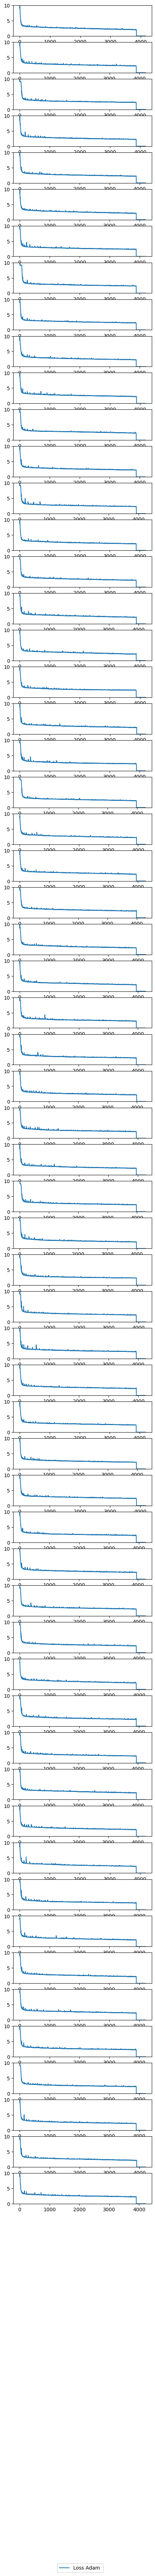

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(5,80))

# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

for i in range(n_models):
  axes[i].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i].set_ylim([0,1e1])

cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]


fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

## Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return lambd_Adam1[i][0].transpose().iloc[-1,:].values[0]

df = pd.DataFrame(columns=['Adam'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam1, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam
Attempt 1,0.499838
Attempt 2,0.499841
Attempt 3,0.499830
Attempt 4,0.499846
Attempt 5,0.499842
Attempt 6,0.499841
Attempt 7,0.499848
Attempt 8,0.499843
Attempt 9,0.499842
Attempt 10,0.499843


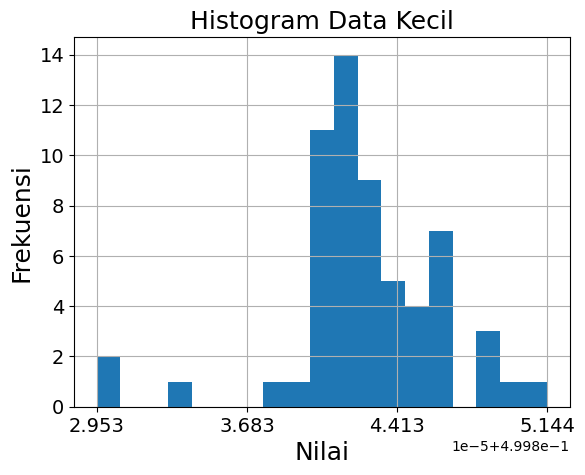

In [ ]:
bins = np.linspace(min(df.Adam), max(df.Adam), 20)  # 20 bins antara 0 dan 0.0001
ax = df.iloc[:, 0].plot(kind='hist', bins=bins, align='mid')

plt.xticks(np.linspace(min(df.Adam), max(df.Adam), 4))  # Misal xtick tiap 0.00001
plt.xlabel("Nilai",fontsize=18)
plt.ylabel("Frekuensi",fontsize=18)
plt.title("Histogram Data Kecil",fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=14)  # misal 14
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))


beta         KS=0.1555, p=0.09856, params=(np.float64(3461381.792703595), np.float64(22.460053674259278), np.float64(-2.2391838251243117), np.float64(2.739044160312952))
norm         KS=0.1688, p=0.05781, params=(np.float64(0.4998425672451655), np.float64(3.7689722236794174e-06))
lognorm      KS=0.1688, p=0.05781, params=(np.float64(4.985490732173421e-07), -7.060041199987623, np.float64(7.559883767231849))
invgauss     KS=0.2024, p=0.01247, params=(np.float64(0.008527371553202143), np.float64(0.49979830509377676), np.float64(0.005179835336696631))
uniform      KS=0.3986, p=4.088e-09, params=(0.4998295307159424, 2.1904706954900544e-05)
expon        KS=0.4758, p=5.35e-13, params=(0.4998295307159424, 1.3036529223131588e-05)
fisk         KS=0.4976, p=2.967e-14, params=(np.float64(94080294964.44336), np.float64(-87656767.18744287), np.float64(87656767.68728542))
gamma        KS=0.5610, p=2.49e-18, params=(np.float64(0.07855635985960144), np.float64(0.49982953071594227), np.float64(1.3056720

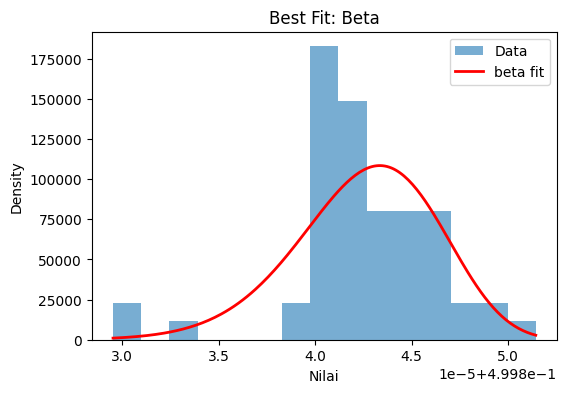

Mean: 0.49984256232122437


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# If df is a DataFrame, pick the column you want to fit:
data = df.iloc[:, 0].to_numpy()  # 1D array

distributions = [
    stats.norm,          # Normal
    stats.expon,         # Exponential
    stats.gamma,         # Gamma
    stats.beta,          # Beta
    stats.lognorm,       # Lognormal
    stats.uniform,       # Uniform
    stats.invgauss,      # Inverse Gaussian
    stats.burr,          # Burr
    stats.fisk,          # Fisk (log-logistic)
    stats.gengamma       # Generalized Gamma
]

results = {}

# Fit tiap distribusi dan uji KS
for dist in distributions:
    try:
        params = dist.fit(data)
        ks_stat, ks_pval = stats.kstest(data, dist.cdf, args=params)
        results[dist.name] = {
            "KS_stat": float(ks_stat),
            "p_value": float(ks_pval),
            "params": params
        }
    except Exception as e:
        results[dist.name] = {"KS_stat": np.inf, "p_value": 0, "params": None}
        print(f"Gagal fit {dist.name}: {e}")

# Urutkan dari KS terkecil
sorted_results = sorted(results.items(), key=lambda x: x[1]["KS_stat"])

# Tampilkan hasil
for name, res in sorted_results:
    if res["params"] is not None:
        print(f"{name:12s} KS={res['KS_stat']:.4f}, p={res['p_value']:.4g}, params={res['params']}")

# Plot best fit
best_name, best_info = sorted_results[0]
best_dist = getattr(stats, best_name)
params = best_info["params"]

x = np.linspace(min(data), max(data), 200)
pdf = best_dist.pdf(x, *params)

plt.figure(figsize=(6,4))
plt.hist(data, bins=15, density=True, alpha=0.6, label="Data")
plt.plot(x, pdf, 'r-', lw=2, label=f"{best_name} fit")
plt.title(f"Best Fit: {best_name.capitalize()}")
plt.xlabel("Nilai")
plt.ylabel("Density")
plt.legend()
plt.show()

params = stats.beta.fit(data)
mean = stats.beta.mean(*params)
print("Mean:", mean)

In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

Adam    0.499843
dtype: float64
             Adam
Average  0.499843
StdDev   0.000004
CV       0.000008


# Pelatihan Kasus Forward

In [ ]:
n_models = 2

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

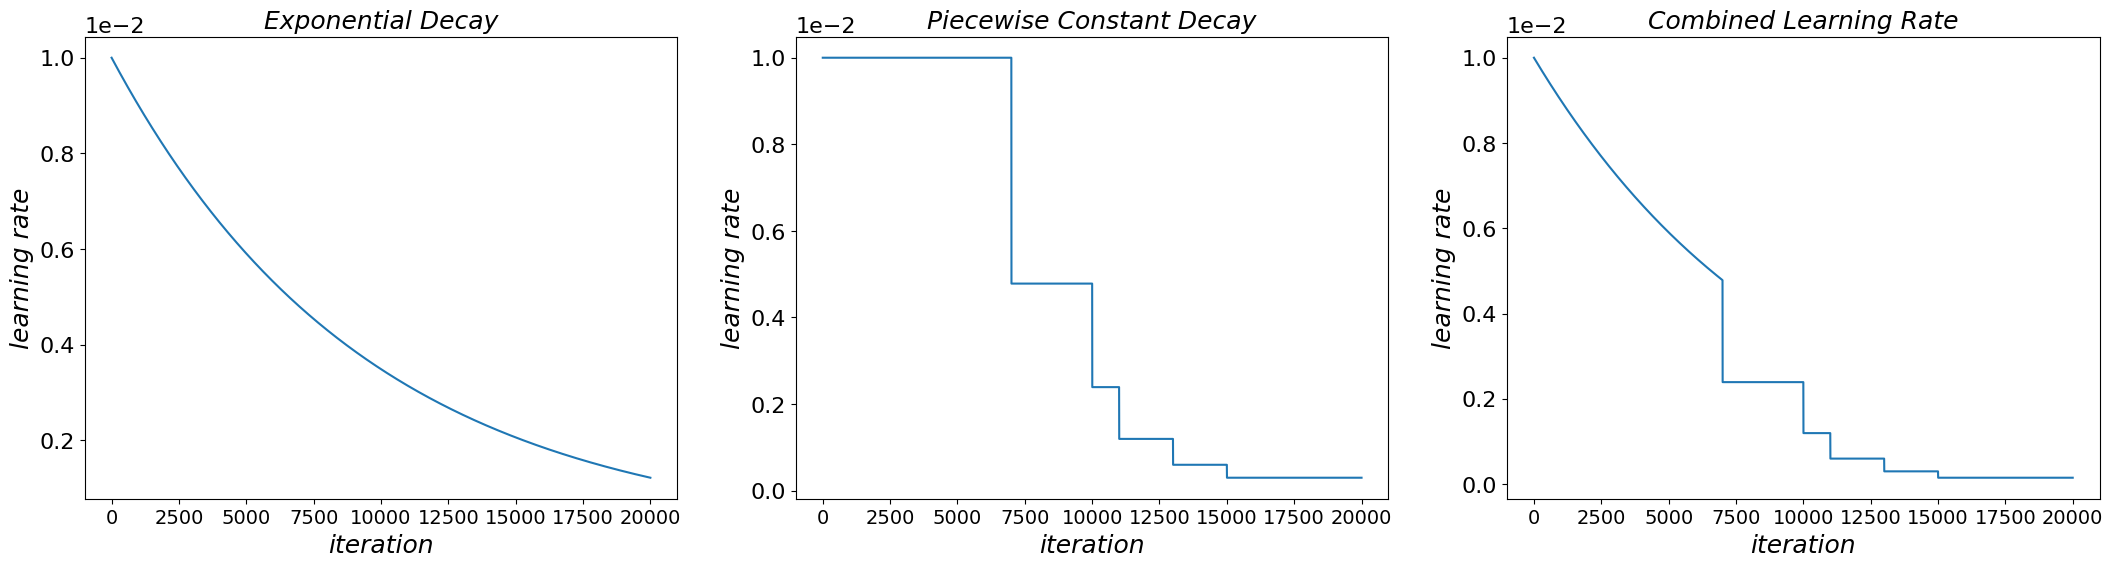

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(26, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic',fontsize =18)
plt.ylabel('learning rate', fontstyle='italic',fontsize =18)
plt.xticks(np.arange(0, N+1, 2500),fontsize =14)
plt.yticks(fontsize=16)
plt.ticklabel_format(axis='y', scilimits=(0,0))
ax = plt.gca()  # Get current axis
ax.yaxis.get_offset_text().set_fontsize(16)  # Adjust scientific notation font size

plt.title('Exponential Decay', y=1, fontstyle='italic',fontsize=18)

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic',fontsize =18)
plt.ylabel('learning rate', fontstyle='italic',fontsize =18)
plt.xticks(np.arange(0, N+1, 2500),fontsize =14)
plt.yticks(fontsize=16)
plt.ticklabel_format(axis='y', scilimits=(0,0))
ax = plt.gca()  # Get current axis
ax.yaxis.get_offset_text().set_fontsize(16)  # Adjust scientific notation font size

plt.title('Piecewise Constant Decay', y=1, fontstyle='italic',fontsize=18)

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic', fontsize=18)
plt.ylabel('learning rate', fontstyle='italic', fontsize=18)
plt.xticks(np.arange(0, N+1, 2500), fontsize=14)
plt.yticks(fontsize=16)
plt.ticklabel_format(axis='y', scilimits=(0,0))

ax = plt.gca()  # Get current axis
ax.yaxis.get_offset_text().set_fontsize(16)  # Adjust scientific notation font size

plt.title('Combined Learning Rate', y=1, fontstyle='italic', fontsize=18)




In [ ]:
pred_lambda = [0.49984256232122437]


In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models
batch_size = 4096

for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, W_u, W_v,timeout=timeout,batch_size=batch_size)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

--------------------------------------------------
Model Iteration: 1, Lambda Iteration: 1
--------------------------------------------------


Adam - Combined Learning Rate



/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
PDE Loss: 1.94077458e-12 Data Loss: 2.91727018 Total Loss: 29.1727028
PDE Loss: 1.94563896e-12 Data Loss: 2.78192592 Total Loss: 27.8192596
PDE Loss: 1.73829093e-12 Data Loss: 2.4986124 Total Loss: 24.986124
PDE Loss: 1.92276403e-12 Data Loss: 3.15055871 Total Loss: 31.5055866
PDE Loss: 1.47526772e-12 Data Loss: 2.70725131 Total Loss: 27.0725136
PDE Loss: 1.81935803e-12 Data Loss: 2.71046519 Total Loss: 27.1046524
PDE Loss: 1.85906932e-12 Data Loss: 3.26128817 Total Loss: 32.6128807
PDE Loss: 1.88718464e-12 Data Loss: 2.63717771 Total Loss: 26.3717766
PDE Loss: 1.77276553e-12 Data Loss: 2.59359479 Total Loss: 25.9359474
PDE Loss: 2.05684558e-12 Data Loss: 2.68242931 Total Loss: 26.8242931
PDE Loss: 2.01825362e-12 Data Loss: 2.21576047 Total Loss: 22.1576042
PDE Loss: 2.22890803e-12 Data Loss: 2.5247767 Total Loss: 25.2477665
PDE Loss: 3.13671658e-12 Data Loss: 2.87867641 Total Loss: 28.7867641
PDE Loss: 7.34679071e-12 Data Loss: 2.9046

In [ ]:
path = dir + "NO2_Model/GridedJabar_Fourier_fwd_tanh/"


In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

In [ ]:
n_models = 5

arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'tanh', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

models_Adam_comb = [None]*n_models # Initialize models_Adam_comb with the correct size

for i in range(0, n_models):
    models_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))
        _ = models_Adam_comb[i][j](tf.zeros((1, 3)))
        models_Adam_comb[i][j].load_weights(
            path + "_" + str(i) + "_model_Adam_comb_" + str(j) + ".weights.h5"
        )


hists_Adam_comb = [None] * n_models

for i in range(0,n_models):
    hists_Adam_comb[i] = []
    for j in range(len(pred_lambda)):
        hists_Adam_comb[i].append(pd.read_csv(path + "/loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv",header=None))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however 

## Grafik Loss

len Atempt-0 Lambda ke- 0:  27
\\
len Atempt-1 Lambda ke- 0:  26
\\
len Atempt-2 Lambda ke- 0:  27
\\
len Atempt-3 Lambda ke- 0:  27
\\
len Atempt-4 Lambda ke- 0:  27
\\


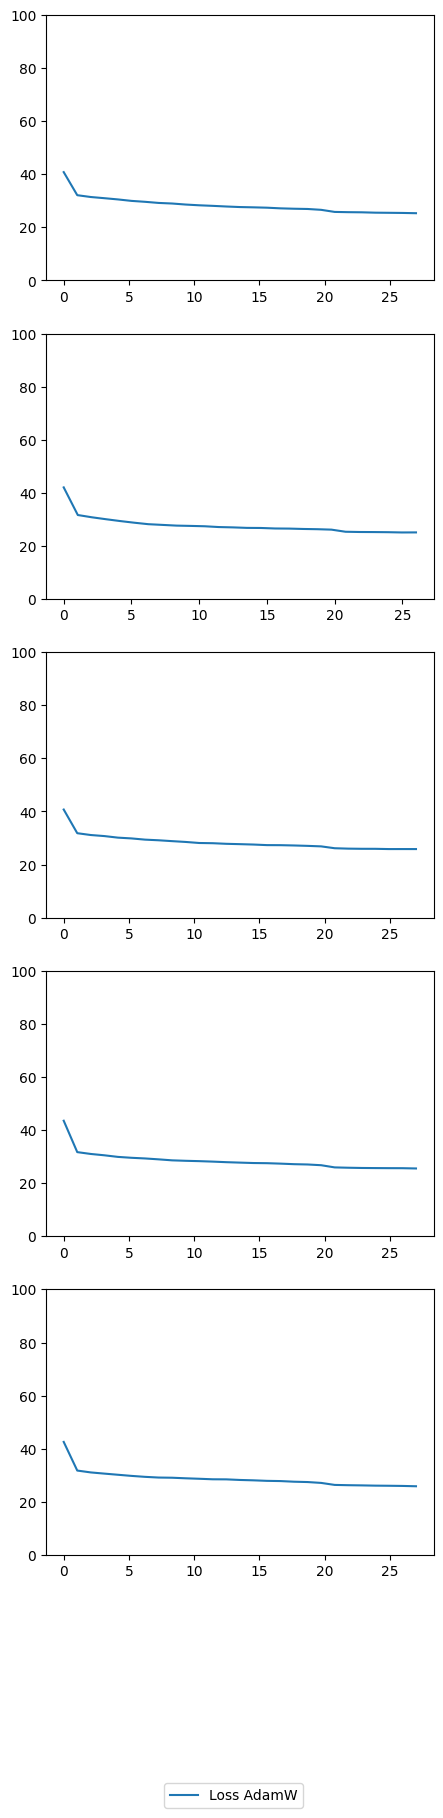

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(5,20))

for i in range(n_models):
  for j in range(len(pred_lambda)):
    axes[i].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
    axes[i].set_ylim([0,100])
  # for j in range(len(pred_lambda)):
  #   axes[j].plot(np.linspace(0, len(hists_Adam_comb[i][j]),len(hists_Adam_comb[i][j])), hists_Adam_comb[i][j])
  #   axes[j].set_ylim([0,5e4])


    print(f"len Atempt-{i} Lambda ke- {j}: ",len(hists_Adam_comb[i][j]))
  print("\\\\")

  rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(1.000983, 15.190058)"
Attempt 2,"(0.9977464, 15.2240305)"
Attempt 3,"(1.003046, 15.035638)"
Attempt 4,"(1.0139177, 15.612444)"
Attempt 5,"(1.0026419, 15.076152)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam  1.003667  0.006099  0.006076  15.227664  0.228754  0.015022


In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())

preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam'])
initial_lambdas = pred_lambda

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam
Attempt 1,"(1.004505, 15.256246)"
Attempt 2,"(1.0022215, 15.299721)"
Attempt 3,"(1.0063555, 15.094501)"
Attempt 4,"(1.0185776, 15.699138)"
Attempt 5,"(1.0056787, 15.134452)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

      mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam  1.007468  0.006406  0.006359  15.296811  0.240214  0.015704


In [ ]:
weights = models_Adam_comb[2][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-1.26640165e+00  9.84279335e-01  6.93358714e-03 -6.19649515e-02
  -9.38491151e-03  2.28627801e+00  1.55174127e-02 -1.55709954e-02
   1.09787351e-02 -1.24186136e-01 -3.96690797e-03 -8.51171911e-01
  -1.81871140e+00  2.65052915e-02  5.31789362e-01  3.47251771e-03
  -1.20015712e-02  4.47896868e-02  6.01221099e-02  8.14924948e-03
  -1.24949300e+00  6.42787814e-02  4.00412351e-01  1.87363887e+00
  -1.71382332e+00  4.58629876e-02  8.56756687e-01 -6.53265297e-01
  -2.87223980e-02  8.43521506e-02 -7.49524534e-01  1.56687107e-02
   1.11168192e-03  1.95272660e+00 -2.26100254e+00 -7.02971637e-01
   1.72849625e-01 -3.79299283e-01 -1.27526820e-01 -1.41472355e-01
  -6.10076683e-03 -2.06976548e-01  3.32463741e+00  2.54742533e-01
  -1.44846511e+00  1.12276180e-02  2.87752092e-01  6.63005531e-01
   3.42371273e+00 -2.39261389e+00 -8.18609376e-04  2.32199049e+00
   9.06261988e-03  1.16048027e-02 -6.13200009e-01  1.30076897e+00
   2.81939292e+00  8.20194036e-02  2.18685961e+00 